In [10]:
import sys
import os

# add project root to PYTHONPATH
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.cascade_engine import run_cascade_simulation
import numpy as np
import matplotlib.pyplot as plt


In [11]:
base_params = {
    "S0": 100.0,
    "mu": 0.0,
    "sigma": 0.6,
    "T": 1.0,
    "N": 252,
    "Q": 1.0,
    "LT": 0.8,
    "oracle_step": 12,
    "eps": 0.02,
    "delta": 0.05,
}

In [12]:
beta_grid = np.linspace(0.01, 0.12, 15)
lambda_grid = np.linspace(0.0005, 0.01, 15)

phase = np.zeros((len(beta_grid), len(lambda_grid)))

In [13]:
n_agents = 500
n_seeds = 10

for i, beta in enumerate(beta_grid):
    for j, lam in enumerate(lambda_grid):

        params = base_params.copy()
        params["beta"] = beta
        params["impact_lambda"] = lam

        outcomes = []

        for seed in range(n_seeds):
            res = run_cascade_simulation(
                params,
                n_agents=n_agents,
                seed=seed
            )
            outcomes.append(res["final_liquidation_fraction"])

        phase[i, j] = np.mean(outcomes)

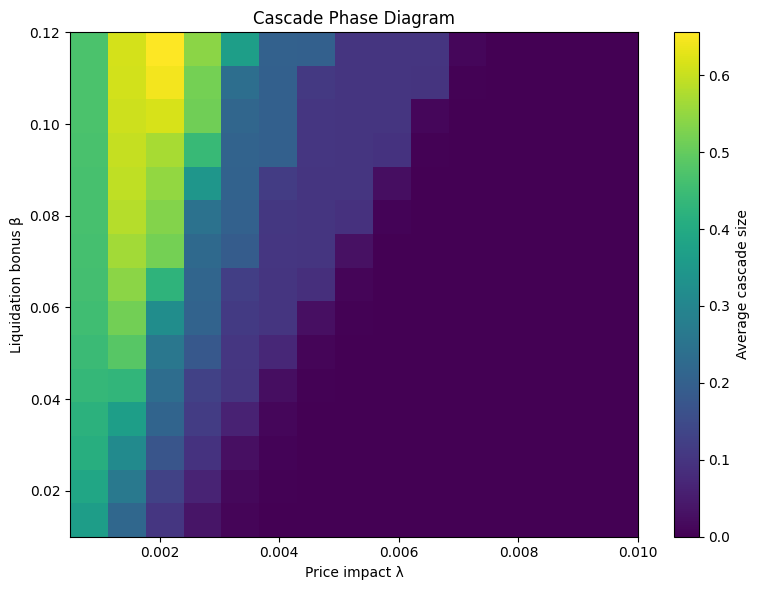

In [ ]:
plt.figure(figsize=(8, 6))

plt.imshow(
    phase,
    origin="lower",
    aspect="auto",
    extent=[
        lambda_grid[0], lambda_grid[-1],
        beta_grid[0], beta_grid[-1],
    ],
    cmap="viridis"
)

plt.colorbar(label="Average cascade size")

plt.xlabel("Price impact λ")
plt.ylabel("Liquidation bonus β")
plt.title("Cascade Phase Diagram")

plt.tight_layout()

# ✅ SAVE FIGURE
plt.savefig("figures/cascade.png", dpi=200)

plt.show()